<a href="https://colab.research.google.com/github/chin0308/Research_Papers/blob/main/diffusion_equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow matplotlib

[Adam] Epoch 0: Loss = 0.396811
[Adam] Epoch 300: Loss = 0.002209
[Adam] Epoch 600: Loss = 0.001543
[Adam] Epoch 900: Loss = 0.001376
[Adam] Epoch 1200: Loss = 0.001289
[Adam] Epoch 1500: Loss = 0.001174
[Adam] Epoch 1800: Loss = 0.001083
[Adam] Epoch 2100: Loss = 0.001067
[Adam] Epoch 2400: Loss = 0.001055
[Adam] Epoch 2700: Loss = 0.001043
[L-BFGS] Starting fine-tuning...
Final Test MSE: 0.13215265
[Adam] Epoch 0: Loss = 0.596845
[Adam] Epoch 300: Loss = 0.075406
[Adam] Epoch 600: Loss = 0.015220
[Adam] Epoch 900: Loss = 0.006902
[Adam] Epoch 1200: Loss = 0.004981
[Adam] Epoch 1500: Loss = 0.003926
[Adam] Epoch 1800: Loss = 0.005610
[Adam] Epoch 2100: Loss = 0.002743
[Adam] Epoch 2400: Loss = 0.002310
[Adam] Epoch 2700: Loss = 0.002017
[L-BFGS] Starting fine-tuning...
Final Test MSE: 0.00164203


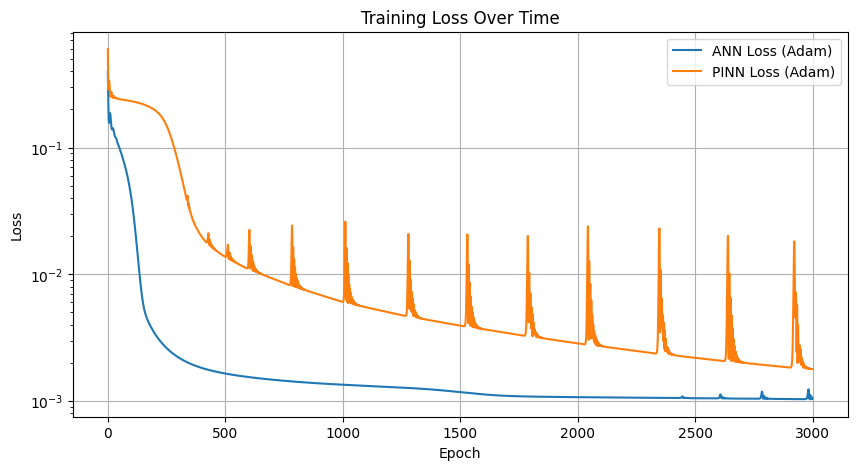

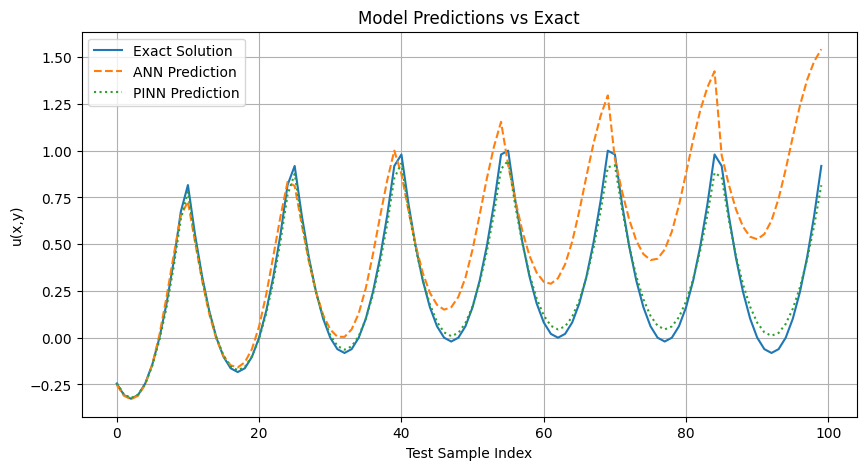

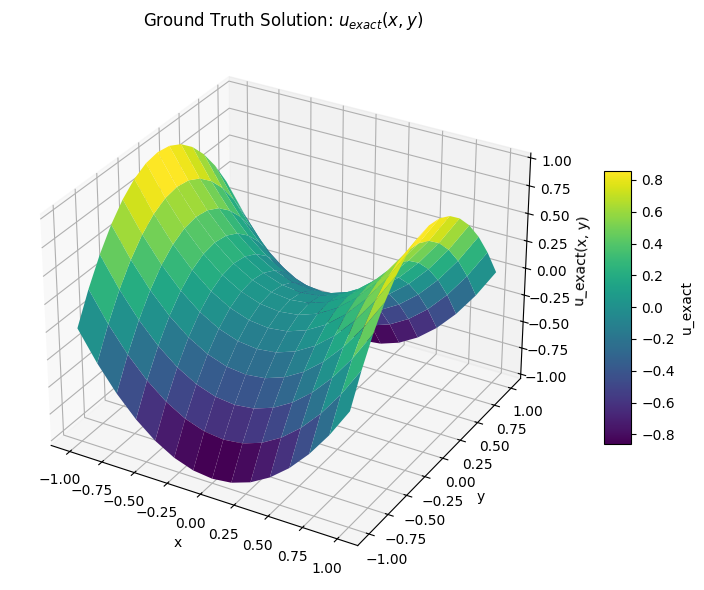

In [ ]:
# Import libraries for numerical computation, plotting, and deep learning
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
# Set random seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)
# Load dataset with x, y coordinates and both exact and noisy solution values
df = pd.read_csv("/content/modified_diffusion_data.csv")
X = df[['x', 'y']].values               # Coordinates (features)
u_exact = df['u_exact'].values         # Ground truth solution
u_noisy = df['u_noisy'].values         # Noisy measurements (training data)
# Use a subset for training (first 50 points) and testing (next 100 points)
X_train, X_test = X[:50], X[50:150]
y_train, y_test = u_noisy[:50], u_exact[50:150]  # Noisy train, exact test targets
# Convert to PyTorch tensors for use with neural networks
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_test_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
# Generate random collocation points in domain [-1, 1] x [-1, 1] for enforcing PDE
n_collocation = 1000
x_colloc = 2 * np.random.rand(n_collocation, 2) - 1
x_colloc_torch = torch.tensor(x_colloc, dtype=torch.float32)
# Neural network model used for both ANN and PINN (2 inputs → 64 → 64 → 1)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),               # Tanh activation for smooth gradients
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)         # Output is scalar u(x, y)
        )
    def forward(self, x):
        return self.net(x)
# Computes residual of Laplace equation ∇²u = 0 at collocation points
def pinn_loss(model, x):
    x.requires_grad = True                    # Enable gradient tracking
    u = model(x)                              # Forward pass
    grads = torch.autograd.grad(outputs=u, inputs=x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grads[:, 0:1]                       # ∂u/∂x
    u_y = grads[:, 1:2]                       # ∂u/∂y
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    D = 1.0                                   # Diffusion coefficient
    residual = D * (u_xx + u_yy)              # Laplacian (∇²u)
    return torch.mean(residual**2)            # MSE of PDE residual
# Dirichlet boundary: u(x, y) = x² - y² on corners of the domain
def boundary_loss(model):
    xb = torch.tensor([[x, y] for x in [-1, 1] for y in [-1, 1]], dtype=torch.float32)
    ub = xb[:, 0]**2 - xb[:, 1]**2            # Analytical solution at boundary
    ub = ub.view(-1, 1)
    return torch.mean((model(xb) - ub) ** 2)  # MSE between predicted and true BC
def train_hybrid(model, X_train, y_train, X_test, y_test, x_colloc, use_pinn=True, pde_weight=20.0, bc_weight=5.0):
    mse = nn.MSELoss()
    adam = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []
    # ------------------ Stage 1: Adam Optimization ------------------
    for epoch in range(3000):
        model.train()
        adam.zero_grad()
        pred = model(X_train)
        data_loss = mse(pred, y_train)
        # Add PINN losses if enabled
        if use_pinn:
            pde = pinn_loss(model, x_colloc)
            bc = boundary_loss(model)
            loss = data_loss + pde_weight * pde + bc_weight * bc
        else:
            loss = data_loss
        loss.backward()
        adam.step()
        losses.append(loss.item())
        if epoch % 300 == 0:
            print(f"[Adam] Epoch {epoch}: Loss = {loss.item():.6f}")
    def closure():
        lbfgs.zero_grad()
        pred = model(X_train)
        data_loss = mse(pred, y_train)
        if use_pinn:
            pde = pinn_loss(model, x_colloc)
            bc = boundary_loss(model)
            loss = data_loss + pde_weight * pde + bc_weight * bc
        else:
            loss = data_loss
        loss.backward()
        return loss
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-9)
    print("[L-BFGS] Starting fine-tuning...")
lbfgs.step(closure)
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test).numpy()
        mse_error = np.mean((y_test.numpy() - pred_test) ** 2)
    print(f"Final Test MSE: {mse_error:.8f}")
    return pred_test, losses
# Train standard ANN (no physics loss)
ann = Net()
ann_pred, ann_losses = train_hybrid(ann, X_train_torch, y_train_torch, X_test_torch, y_test_torch, x_colloc_torch, use_pinn=False)
# Train PINN (with PDE + boundary constraints)
pinn = Net()
pinn_pred, pinn_losses = train_hybrid(pinn, X_train_torch, y_train_torch, X_test_torch, y_test_torch, x_colloc_torch, use_pinn=True)
plt.figure(figsize=(10,5))
plt.plot(ann_losses, label="ANN Loss (Adam)")
plt.plot(pinn_losses, label="PINN Loss (Adam)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.legend()
plt.grid(True)
plt.yscale('log')    # Log scale for better visibility
plt.show()
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Exact Solution")
plt.plot(ann_pred, '--', label="ANN Prediction")
plt.plot(pinn_pred, ':', label="PINN Prediction")
plt.xlabel("Test Sample Index")
plt.ylabel("u(x,y)")
plt.title("Model Predictions vs Exact")
plt.legend()
plt.grid(True)
plt.show()